# NBBO consolidation: best bid/offer across fragmented venues

US equities trade on a dozen-plus venues, each publishing its own top of
book. The consolidated best bid and offer (NBBO) — the number your
execution quality is measured against — has to be *derived*: at any instant,
take each venue's latest quote and cross-sectionally best them. That
"latest quote per venue at time t" is exactly an ASOF join, and h5i-db lets
us build a research-grade sampled NBBO in a few SQL statements: a time grid
ASOF-joined against per-venue quotes, then `max(bid)` / `min(ask)` per
instant. Along the way we measure which venue actually sets the inside, how
often the market locks or crosses, and how much tighter the consolidated
spread is than any single venue's.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("mde_nbbo"), create=True)

## 1. Synthesize a fragmented tape

One day of consolidated-style AAPL quotes, fanned out to three venues with
distinct microstructure personalities: each venue re-quotes on the
consolidated updates but occasionally *drops* some (feed gaps — the source
of genuine staleness), adds its own gateway latency, and skews its price a
tick away from — or occasionally inside — the reference. That mix is what
makes one venue more competitive at the inside than another and lets brief
locked/crossed states appear. Fixed seeds throughout.

In [2]:
quotes = cu.make_quotes(
    symbols=["AAPL"], days=1, quotes_per_day=2_600, seed=11, base_prices={"AAPL": 320.0}
).to_pandas()
rng = np.random.default_rng(5)
TICK = 0.01

VENUES = {
    #        P(miss update), latency (ms), P(1 tick worse), P(1 tick better)
    "ARCA": dict(drop=0.04, lat_ms=3.0, worse=0.25, better=0.02),
    "EDGX": dict(drop=0.08, lat_ms=10.0, worse=0.35, better=0.005),
    "XNAS": dict(drop=0.02, lat_ms=1.5, worse=0.15, better=0.03),
}

parts = []
for venue, v in VENUES.items():
    d = quotes[rng.random(len(quotes)) >= v["drop"]].copy()
    n = len(d)
    d["ts"] = d["ts"] + pd.to_timedelta(rng.exponential(v["lat_ms"], n), unit="ms").round("us")
    d["bid"] = d["bid"] - TICK * (rng.random(n) < v["worse"]) + TICK * (rng.random(n) < v["better"])
    d["ask"] = d["ask"] + TICK * (rng.random(n) < v["worse"]) - TICK * (rng.random(n) < v["better"])
    d["venue"] = venue
    parts.append(d)

venue_quotes = (
    pd.concat(parts)[["ts", "venue", "bid", "ask", "bid_size", "ask_size"]]
    .assign(bid=lambda x: x["bid"].round(2), ask=lambda x: x["ask"].round(2))
    .sort_values(["ts", "venue"], kind="stable")
    .reset_index(drop=True)
)
venue_quotes.assign(spread=venue_quotes["ask"] - venue_quotes["bid"]).groupby("venue").agg(
    quotes=("ts", "count"), avg_spread=("spread", "mean")
).round(4)

,quotes,avg_spread
venue,,
ARCA,2493,0.0603
EDGX,2384,0.0625
XNAS,2532,0.0581


In [3]:
VQ_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("venue", pa.string()),
        pa.field("bid", pa.float64()),
        pa.field("ask", pa.float64()),
        pa.field("bid_size", pa.int64()),
        pa.field("ask_size", pa.int64()),
    ]
)
db.create_table("venue_quotes", VQ_SCHEMA, time_column="ts", sort_key=["ts", "venue"])
db.append("venue_quotes", pa.Table.from_pandas(venue_quotes, preserve_index=False).cast(VQ_SCHEMA),
          note="per-venue AAPL quotes, 1 session, 3 venues")

{'table': 'venue_quotes',
 'sequence': 1,
 'op': 'append',
 'rows_total': 7409,
 'segments_total': 1,
 'segments_added': 1,
 'segments_deduped': 0,
 'committed_at_ns': 1784778591616620418}

## 2. A sampling grid, ASOF-joined per venue

An event-accurate NBBO re-evaluates on *every* quote update; for research,
a sampled NBBO on a regular grid is the standard approximation (error
bounded by the sampling interval — consolidated updates arrive every ~9
seconds here, and we sample every 10). The grid is itself a tiny h5i-db
table: one row per (timestamp, venue), so a single
`asof_join(grid, venue_quotes, ..., 'venue')` snapshots each venue's
prevailing quote at each instant. The 60-second `tolerance` (raw
microseconds) declares a venue's quote stale — NULL — rather than letting a
dead book linger at the inside.

One habit worth keeping in any ASOF pipeline: assert the join returned
exactly one row per grid row (a LEFT ASOF join is 1:1 with its left side),
so a sizing or key mistake fails loudly instead of skewing the book.

In [4]:
open_ts = venue_quotes["ts"].min().ceil("10s")
close_ts = pd.Timestamp("2026-06-01 20:00", tz="UTC")
grid_times = pd.date_range(open_ts, close_ts, freq="10s", inclusive="left")

grid = pd.DataFrame(
    {
        "ts": np.repeat(grid_times, len(VENUES)),
        "venue": np.tile(sorted(VENUES), len(grid_times)),
    }
)
GRID_SCHEMA = pa.schema(
    [pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False), pa.field("venue", pa.string())]
)
db.create_table("nbbo_grid", GRID_SCHEMA, time_column="ts", sort_key=["ts", "venue"])
db.append("nbbo_grid", pa.Table.from_pandas(grid, preserve_index=False).cast(GRID_SCHEMA))
print(f"grid: {len(grid_times)} instants x {len(VENUES)} venues = {len(grid):,} rows")

grid: 2339 instants x 3 venues = 7,017 rows


In [5]:
STALE_US = 60 * 1_000_000
db.sql(
    f"""
    SELECT ts, venue, bid, ask, ts_right AS quoted_at
    FROM asof_join('nbbo_grid', 'venue_quotes', 'ts', 'ts', 'venue', 'backward', {STALE_US})
    ORDER BY ts, venue
    LIMIT 6
    """
).to_pandas()

,ts,venue,bid,ask,quoted_at
0,2026-06-01 13:30:10+00:00,ARCA,319.98,320.07,2026-06-01 13:30:07.006055+00:00
1,2026-06-01 13:30:10+00:00,EDGX,319.98,320.08,2026-06-01 13:30:07.006704+00:00
2,2026-06-01 13:30:10+00:00,XNAS,319.98,320.04,2026-06-01 13:30:06.221232+00:00
3,2026-06-01 13:30:20+00:00,ARCA,319.98,320.06,2026-06-01 13:30:17.937669+00:00
4,2026-06-01 13:30:20+00:00,EDGX,319.97,320.06,2026-06-01 13:30:17.946724+00:00
5,2026-06-01 13:30:20+00:00,XNAS,319.98,320.05,2026-06-01 13:30:17.933154+00:00


In [6]:
# Trust, but verify: one output row per grid row, and the SQL ASOF must agree
# with an independent pandas merge_asof on a venue's book.
state = db.sql(
    f"""
    SELECT ts, venue, bid, ask
    FROM asof_join('nbbo_grid', 'venue_quotes', 'ts', 'ts', 'venue', 'backward', {STALE_US})
    ORDER BY ts, venue
    """
).to_pandas()
assert len(state) == len(grid), f"ASOF join returned {len(state)} rows for {len(grid)} grid rows"

ref = pd.merge_asof(
    pd.DataFrame({"ts": grid_times}),
    venue_quotes[venue_quotes["venue"] == "XNAS"][["ts", "bid", "ask"]],
    on="ts", tolerance=pd.Timedelta("60s"),
)
chk = state[state["venue"] == "XNAS"].reset_index(drop=True)
assert chk["bid"].equals(ref["bid"]) and chk["ask"].equals(ref["ask"])
print(f"validated: {len(state):,} snapshot rows, XNAS column matches pandas merge_asof exactly")

validated: 7,017 snapshot rows, XNAS column matches pandas merge_asof exactly


## 3. Consolidate and store the NBBO

Bettering across venues is now a plain GROUP BY per grid instant. We
materialize the result as its own table — downstream recipes (execution
benchmarks, effective-spread studies) read `nbbo_10s` without re-running
the consolidation.

In [7]:
nbbo = db.sql(
    f"""
    SELECT ts,
           max(bid)   AS nbb,
           min(ask)   AS nbo,
           count(bid) AS venues_quoting
    FROM asof_join('nbbo_grid', 'venue_quotes', 'ts', 'ts', 'venue', 'backward', {STALE_US})
    GROUP BY ts
    HAVING max(bid) IS NOT NULL AND min(ask) IS NOT NULL
    ORDER BY ts
    """
).to_arrow()

NBBO_SCHEMA = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("nbb", pa.float64()),
        pa.field("nbo", pa.float64()),
        pa.field("venues_quoting", pa.int64()),
    ]
)
db.create_table("nbbo_10s", NBBO_SCHEMA, time_column="ts")
db.append("nbbo_10s", nbbo.cast(NBBO_SCHEMA), note="10s-sampled NBBO from 3 venues")
db.sql("SELECT * FROM nbbo_10s LIMIT 5").to_pandas()

,ts,nbb,nbo,venues_quoting
0,2026-06-01 13:30:10+00:00,319.98,320.04,3
1,2026-06-01 13:30:20+00:00,319.98,320.05,3
2,2026-06-01 13:30:30+00:00,320.04,320.06,3
3,2026-06-01 13:30:40+00:00,320.07,320.11,3
4,2026-06-01 13:30:50+00:00,319.95,320.04,3


## 4. Who sets the inside — and how often does it lock or cross?

Window functions over the per-venue snapshot answer the venue-share
question: at each instant, is this venue's bid equal to the consolidated
best? (Ties count for every venue at the inside.) The same snapshot flags
*locked* (NBB = NBO) and *crossed* (NBB > NBO) states — with independent
per-venue latencies and price skews, brief locks and crossings are a fact
of consolidated life, and any NBBO pipeline must decide how to treat them.

In [8]:
db.sql(
    f"""
    WITH state AS (
        SELECT ts, venue, bid, ask
        FROM asof_join('nbbo_grid', 'venue_quotes', 'ts', 'ts', 'venue', 'backward', {STALE_US})
        WHERE bid IS NOT NULL AND ask IS NOT NULL
    ),
    ranked AS (
        SELECT venue, bid, ask,
               max(bid) OVER (PARTITION BY ts) AS nbb,
               min(ask) OVER (PARTITION BY ts) AS nbo
        FROM state
    )
    SELECT venue,
           round(avg(CASE WHEN bid >= nbb THEN 1.0 ELSE 0.0 END) * 100, 1) AS pct_at_best_bid,
           round(avg(CASE WHEN ask <= nbo THEN 1.0 ELSE 0.0 END) * 100, 1) AS pct_at_best_ask,
           round(avg(ask - bid), 4)                                        AS avg_own_spread
    FROM ranked
    GROUP BY venue
    ORDER BY venue
    """
).to_pandas()

,venue,pct_at_best_bid,pct_at_best_ask,avg_own_spread
0,ARCA,72.8,70.7,0.0596
1,EDGX,60.4,61.1,0.0626
2,XNAS,77.6,82.2,0.0580


In [9]:
db.sql(
    """
    SELECT count(*)                                        AS instants,
           sum(CASE WHEN nbb = nbo THEN 1 ELSE 0 END)      AS locked,
           sum(CASE WHEN nbb > nbo THEN 1 ELSE 0 END)      AS crossed,
           round(avg(CASE WHEN nbb >= nbo THEN 1.0 ELSE 0.0 END) * 100, 2) AS pct_locked_or_crossed
    FROM nbbo_10s
    """
).to_pandas()

,instants,locked,crossed,pct_locked_or_crossed
0,2269,12,58,3.09


## 5. The consolidation dividend: spread vs any single venue

The point of consolidating: the inside spread is tighter than every
individual book, because the best bid and best ask usually live on
*different* venues. One UNION ALL puts the books side by side, and the
session plot shows the NBBO spread hugging the floor below each venue's
own spread.

In [10]:
db.sql(
    f"""
    SELECT venue AS book, round(avg(ask - bid), 4) AS avg_spread_usd
    FROM asof_join('nbbo_grid', 'venue_quotes', 'ts', 'ts', 'venue', 'backward', {STALE_US})
    WHERE bid IS NOT NULL AND ask IS NOT NULL
    GROUP BY venue
    UNION ALL
    SELECT 'NBBO', round(avg(nbo - nbb), 4) FROM nbbo_10s
    ORDER BY avg_spread_usd
    """
).to_pandas()

,book,avg_spread_usd
0,NBBO,0.0500
1,XNAS,0.0580
2,ARCA,0.0596
3,EDGX,0.0626


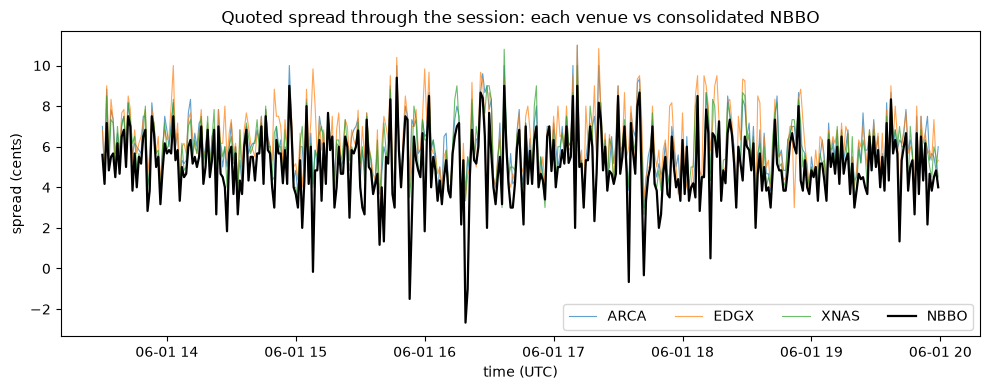

In [11]:
import matplotlib.pyplot as plt

venue_min = db.sql(
    f"""
    SELECT time_bucket('1m', ts) AS m, venue, avg(ask - bid) AS spread
    FROM asof_join('nbbo_grid', 'venue_quotes', 'ts', 'ts', 'venue', 'backward', {STALE_US})
    WHERE bid IS NOT NULL AND ask IS NOT NULL
    GROUP BY m, venue ORDER BY m
    """
).to_pandas()
nbbo_min = db.sql(
    """
    SELECT time_bucket('1m', ts) AS m, avg(nbo - nbb) AS spread
    FROM nbbo_10s GROUP BY m ORDER BY m
    """
).to_pandas()

fig, ax = plt.subplots(figsize=(10, 4))
for venue, g in venue_min.groupby("venue"):
    ax.plot(g["m"], g["spread"] * 100, lw=0.8, alpha=0.7, label=venue)
ax.plot(nbbo_min["m"], nbbo_min["spread"] * 100, lw=1.6, color="black", label="NBBO")
ax.set_title("Quoted spread through the session: each venue vs consolidated NBBO")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("spread (cents)")
ax.legend(ncols=4)
fig.tight_layout()

## Takeaways

- NBBO construction is "latest quote per venue, then best across venues" —
  which maps 1:1 onto `asof_join(grid, venue_quotes, ..., 'venue')` plus a
  GROUP BY. No per-venue loops, no manual state machines.
- The ASOF `tolerance` doubles as a staleness rule: a venue that stops
  quoting drops out of the consolidation instead of pinning a dead price at
  the inside.
- A sampled NBBO is an approximation — honest work states its grid (10s
  here) and remembers that locks/crosses between samples go unseen.
- Materializing `nbbo_10s` as a table makes the consolidation a build
  artifact: versioned, noted, and instantly queryable by every downstream
  execution study.

In [12]:
db.close()